In [1]:
import os

import time
from pathlib import Path

import ml_tools.utils
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
import seaborn as sns

# Grow the GPU memory usage as needed
gpus = tf.config.experimental.list_physical_devices("GPU")
if gpus:
    try:
        # Currently, memory growth needs to be the same across GPUs
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        logical_gpus = tf.config.experimental.list_logical_devices("GPU")
        print(len(gpus), "Physical GPUs,", len(logical_gpus), "Logical GPUs")
    except RuntimeError as e:
        # Memory growth must be set before GPUs have been initialized
        print(e)

from qcore import nhm
import nn_gmm

In [2]:
# Config
# map_data_ffp = Path("/home/claudy/dev/work/code/qcore/qcore/data")
# nshm_ffp = Path("/mnt/mantle_data/seistech/sources/18p6/NZ_FLTmodel_2010.txt")
# val_events_ffp = Path("/home/claudy/dev/work/data/nn_gmm/input_data/validation_events.txt")
# source_rel_data_dir = Path("/home/claudy/dev/work/data/nn_gmm/input_data/source_rel_params")

map_data_ffp = Path("/Users/claudy/dev/work/code/qcore/qcore/data")
nshm_ffp = Path("/Users/claudy/dev/work/mounts/mantle_data/seistech/sources/18p6/NZ_FLTmodel_2010.txt")
val_events_ffp = Path("/Users/claudy/dev/work/mounts/broombroom/dev/work/data/nn_gmm/input_data/validation_events.txt")
source_rel_data_dir = Path("/Users/claudy/dev/work/mounts/broombroom/dev/work/data/nn_gmm/input_data/source_rel_params")


In [3]:
# Load the data
nhm_data = nhm.load_nhm(str(nshm_ffp))
val_faults = ml_tools.utils.load_txt(val_events_ffp)

cybershake_df = pd.read_csv(source_rel_data_dir / "cybershake_v20p4_200.csv", index_col=0)
cybershake_df["fault"] = np.stack(np.char.split(cybershake_df.index.values.astype(str), "_", maxsplit=1), axis=1)[0, :]
cybershake_df["historic"] = False

small_df = pd.read_csv(source_rel_data_dir / "val_small.csv", index_col=0)
small_df["fault"] = small_df.index.values.astype(str)
small_df["historic"] = True

mod_df = pd.read_csv(source_rel_data_dir / "val_moderate.csv", index_col=0)
mod_df["fault"] = mod_df.index.values.astype(str)
mod_df["historic"] = True

# Plotting data
map_data = nn_gmm.NZMapData.load(map_data_ffp)

In [4]:
rupture_df = pd.concat((cybershake_df, small_df, mod_df), axis=0)
val_mask = np.isin(rupture_df.fault, val_faults)

train_faults = [cur_fault for cur_name, cur_fault in nhm_data.items() if cur_name not in val_faults]
val_faults = [cur_fault for cur_name, cur_fault in nhm_data.items() if cur_name in val_faults]

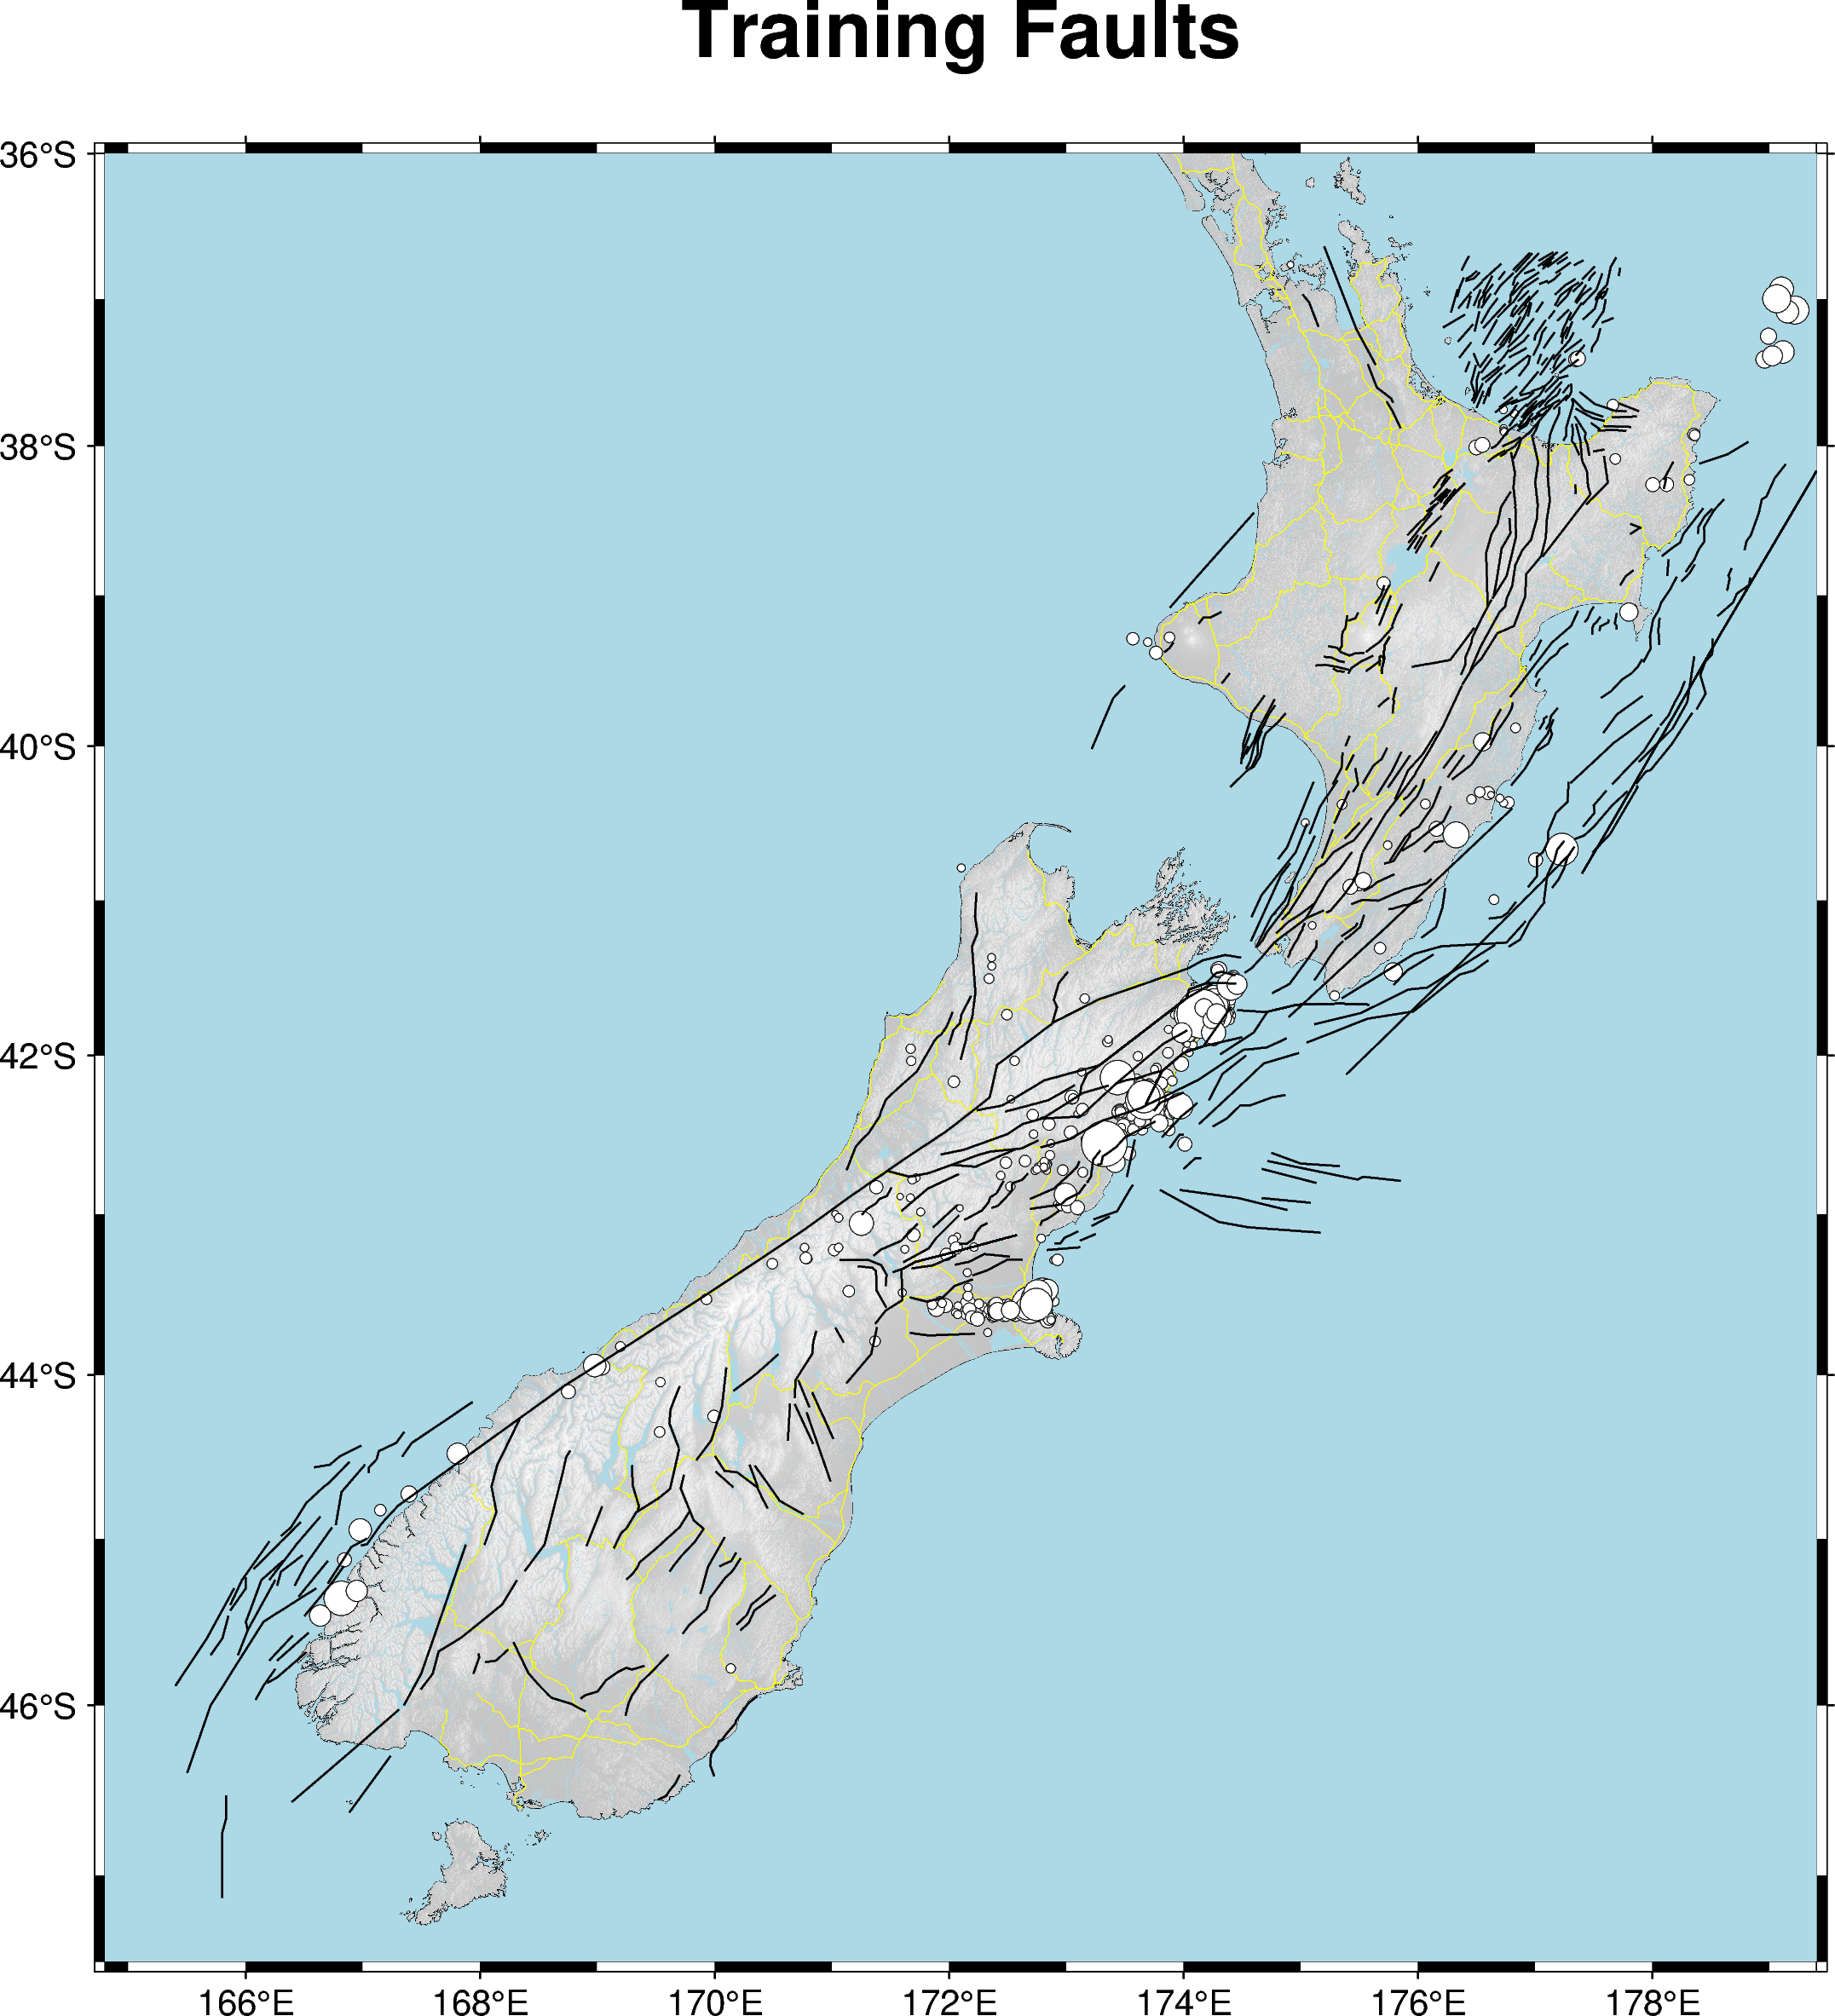

In [5]:
# Training Faults & Historic Events
fig = nn_gmm.faults_plot(rupture_df.loc[~val_mask], train_faults, map_data=map_data, title="Training Faults");
fig.show()

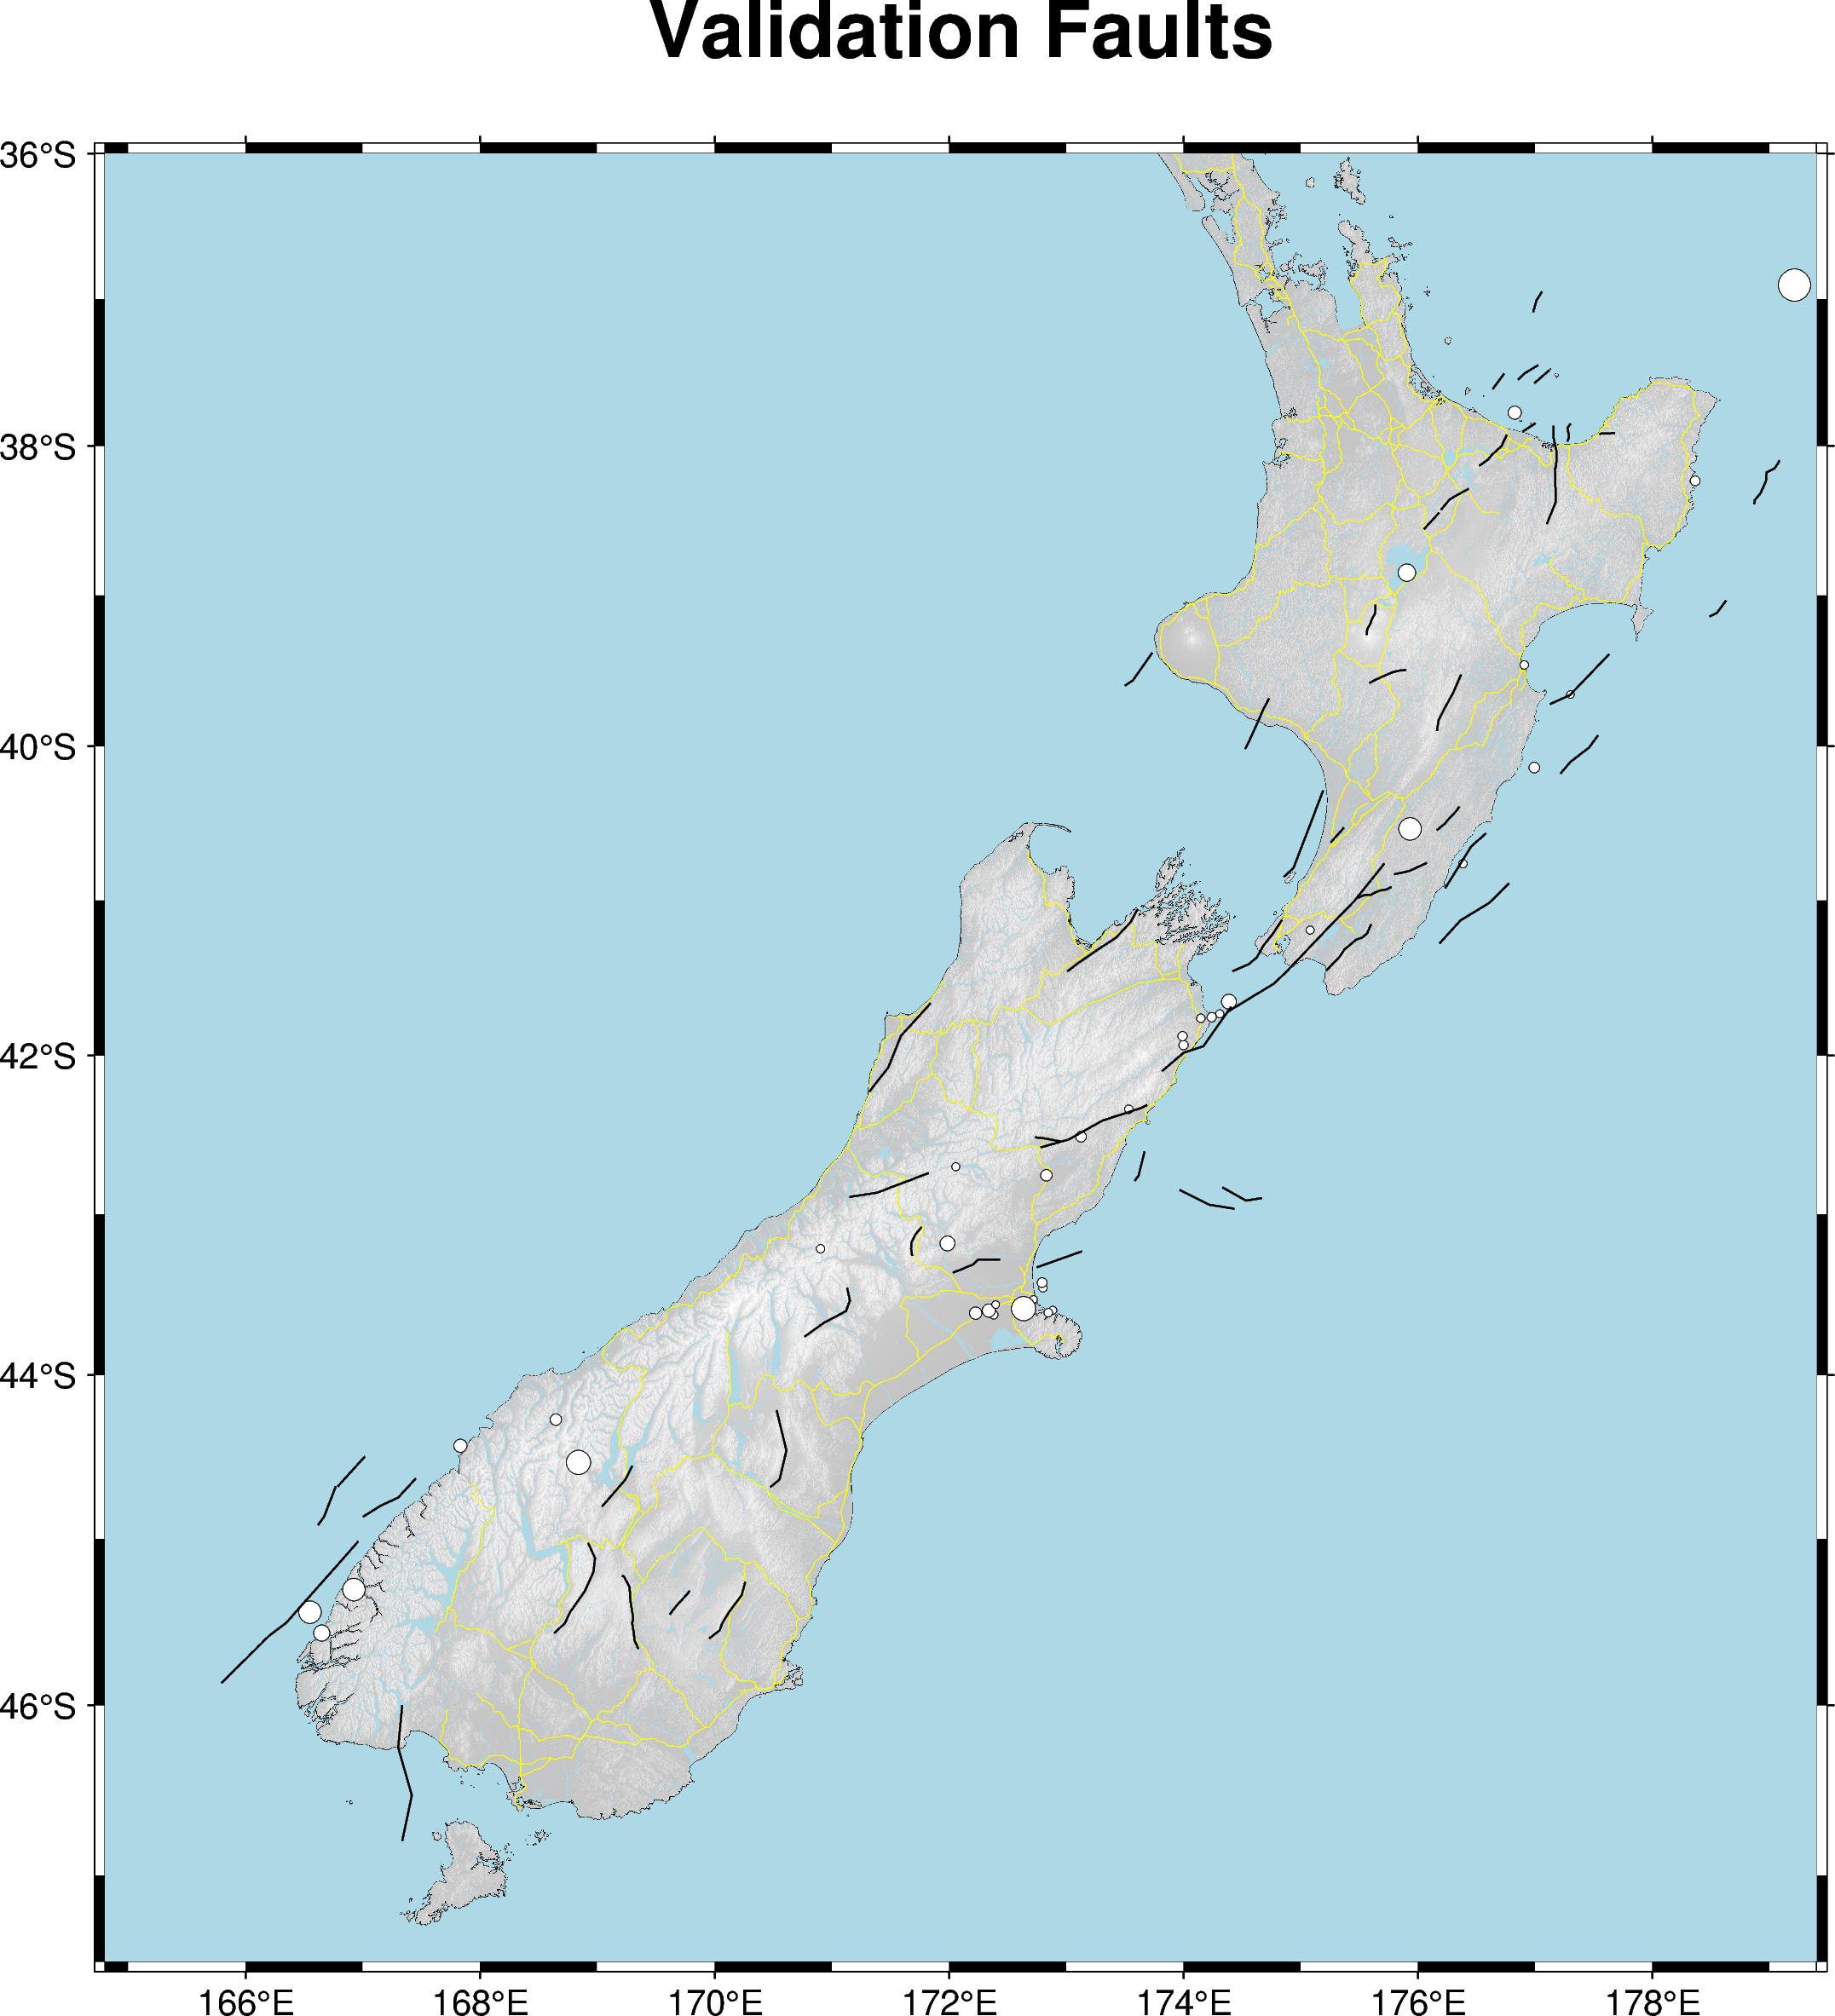

In [6]:
# Training Faults & Historic Events
fig = nn_gmm.faults_plot(rupture_df.loc[val_mask], val_faults, map_data=map_data, title="Validation Faults");
fig.show()

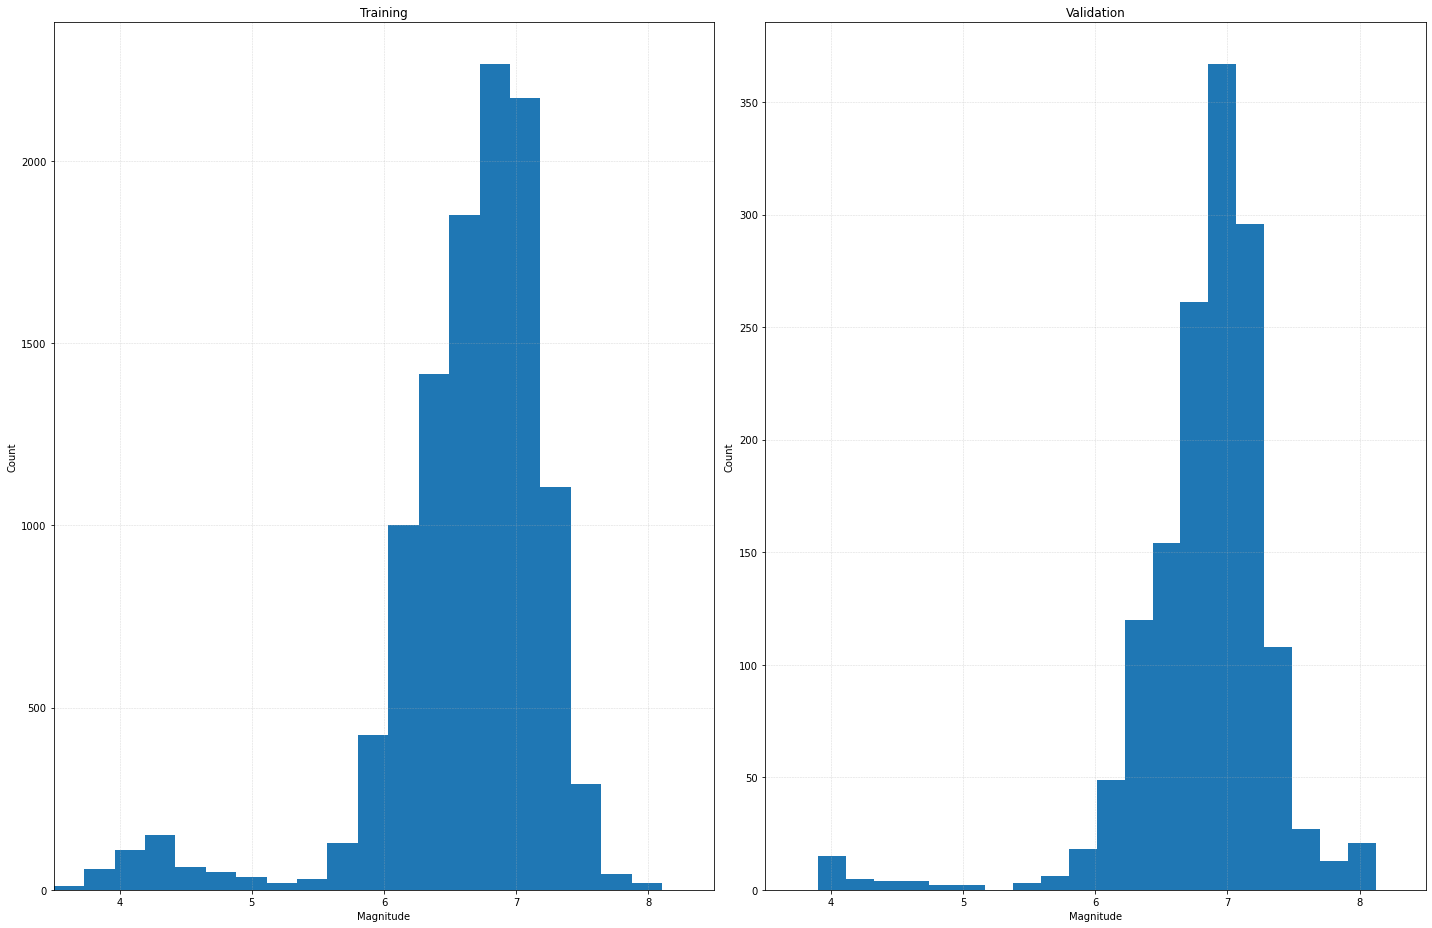

In [7]:
fig = plt.figure(figsize=(20, 13))

ax = fig.add_subplot(1, 2, 1)
ax.set_xlim(3.5, 8.5)
ax.set_title("Training")
ax.set_xlabel(f"Magnitude")
ax.set_ylabel(f"Count")
ax.grid(linewidth=0.5, alpha=0.5, linestyle="--")
ax.hist(rupture_df[~val_mask].mag, bins=20);

ax = fig.add_subplot(1, 2, 2)
ax.set_xlim(3.5, 8.5)
ax.set_title("Validation")
ax.set_xlabel(f"Magnitude")
ax.set_ylabel(f"Count")
ax.grid(linewidth=0.5, alpha=0.5, linestyle="--")
ax.hist(rupture_df[val_mask].mag, bins=20);


fig.tight_layout()

In [8]:
rupture_df.loc[(rupture_df.mag > 7.6).values & (~val_mask)]

,dbottom,dhyp,dip,dtop,hdepth,hlat,hlon,is_point_source,length,mag,rake,shyp,strike,tect_type,width,zbot,ztor,fault,historic
realisation,,,,,,,,,,,,,,,,,,,
TeAnau_REL19,18.042098,4.6923,70.0,0.0,4.41034,-45.591339,167.584656,False,57.5500,7.623687,92.939279,8.0324,204.000,ACTIVE_SHALLOW,19.2,18.042098,0.0,TeAnau,False
TeAnau_REL36,18.042098,7.8150,70.0,0.0,7.28867,-45.579468,167.576263,False,57.5500,7.631571,66.539796,6.7788,204.000,ACTIVE_SHALLOW,19.2,18.042098,0.0,TeAnau,False
MilfordB1_REL07,18.003538,21.0160,25.0,0.0,8.84538,-44.418121,167.840225,False,30.5500,7.714473,84.016415,6.7435,46.000,ACTIVE_SHALLOW,42.6,18.003538,0.0,MilfordB1,False
MilfordB1_REL02,18.003538,28.7627,25.0,0.0,12.08100,-44.535339,167.752701,False,30.5500,7.628675,66.571613,-7.0870,46.000,ACTIVE_SHALLOW,42.6,18.003538,0.0,MilfordB1,False
MilfordB1_REL18,18.003538,20.6317,25.0,0.0,8.67730,-44.470810,167.722473,False,30.5500,7.675744,104.662801,-4.2824,46.000,ACTIVE_SHALLOW,42.6,18.003538,0.0,MilfordB1,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
OpouaweUruti_REL20,10.027487,3.0909,40.0,0.0,1.96962,-41.571640,175.872208,False,35.5000,7.624420,69.677113,1.9988,250.250,ACTIVE_SHALLOW,15.6,10.027487,0.0,OpouaweUruti,False
OpouaweUruti_REL02,10.027487,9.0689,40.0,0.0,5.76634,-41.480850,176.104126,False,35.5000,7.630551,105.168208,-21.6223,250.250,ACTIVE_SHALLOW,15.6,10.027487,0.0,OpouaweUruti,False
WhiteCk_REL07,14.990664,13.8784,45.0,0.0,9.49629,-41.442047,172.322632,False,15.1625,7.697143,106.510858,7.2313,97.875,ACTIVE_SHALLOW,21.2,14.990664,0.0,WhiteCk,False
